In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")
print("Dataset Path:", path)

train_dir = os.path.join(path, "Dataset", "Train")
val_dir = os.path.join(path, "Dataset", "Validation")
test_dir = os.path.join(path, "Dataset", "Test")


Using Colab cache for faster access to the 'deepfake-and-real-images' dataset.
Dataset Path: /kaggle/input/deepfake-and-real-images


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
val_data = datasets.ImageFolder(val_dir, transform=transform)
test_data = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print("Classes:", train_data.classes)


Classes: ['Fake', 'Real']


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.last_channel, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 125MB/s]


In [ ]:
for epoch in range(3):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")


Epoch 1, Loss: 0.06969646801743572
Epoch 2, Loss: 0.036064219423831013
Epoch 3, Loss: 0.02668884321934985


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 96.56%


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

NameError: name 'model' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [ ]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[5004  488]
 [ 610 4803]]


In [ ]:
print(classification_report(all_labels, all_preds, target_names=["Fake","Real"]))

              precision    recall  f1-score   support

        Fake       0.89      0.91      0.90      5492
        Real       0.91      0.89      0.90      5413

    accuracy                           0.90     10905
   macro avg       0.90      0.90      0.90     10905
weighted avg       0.90      0.90      0.90     10905



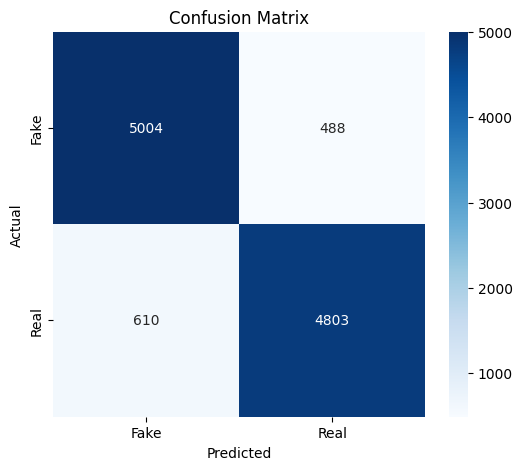

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
torch.save(model.state_dict(), "deepfake_detector.pth")

In [ ]:
from google.colab import files
files.download("deepfake_detector.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image

img = Image.open("/content/real.png").convert("RGB")
img = transform(img).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(img)
    _, pred = torch.max(output, 1)

classes = ["Fake","Real"]

print("Prediction:", classes[pred.item()])

Prediction: Real
